
# Triadic Cell Notebook v28
## Retrieve mask → missing mask → fold field → declared value

This notebook continues directly from v27.

v27 calibrated the controller to operate near:

- **35% retrieve**
- **65% grow**

The next move is to stop returning only a mode and return the full field:

$$
Q \to (\text{retrieve mask},\ \text{missing mask},\ \text{fold field},\ \text{declared value})
$$

This is the practical runtime shape:

1. **retrieve mask**
   - where the query already matches a closure strongly enough

2. **missing mask**
   - where structure is absent relative to the best closure

3. **fold field**
   - the signed correction field that says how the query should move

4. **declared value**
   - the late readout after applying the fold

The controller still uses the triad:

- shape
- complement
- declared value



## Practical meaning

This is still runtime logic, not base-model training.

The query enters as a shape.
The runtime chooses the best closure chain.
Then instead of only deciding retrieve/grow, it emits:

- **retrieve mask**
- **missing mask**
- **fold field**
- **declared value**

So the AI-side interpretation becomes:

- retrieve what is already there
- expose what is missing
- provide the direction of repair
- only then render the late value


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Query corruption


In [3]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Candidate evaluation with field outputs


In [4]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]

    retrieve_fit = cosine_similarity(query, s0)

    missing = normalize01(np.maximum(s0 - query, 0.0))
    excess = normalize01(np.maximum(query - s0, 0.0))
    residual = s0 - query
    residual_energy = float(np.mean(np.abs(residual)))

    folded0 = normalize01(query + missing - 0.25 * excess)
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.40 * residual_energy
        + 0.20 * np.mean(missing)
        + 0.20 * np.mean(excess)
        + 0.20 * (1.0 - retrieve_fit)
    )

    closure_score = (
        0.70 * retrieve_fit
        - 0.85 * bridge_energy
        - 0.45 * np.mean(missing)
        - 0.25 * residual_energy
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "residual_energy": float(residual_energy),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "missing": missing,
        "excess": excess,
        "residual": residual,
        "folded0": folded0,
        "projected1": projected1,
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["closure_score"], reverse=True)

    best = results[0]
    second = results[1]
    margin = float(best["closure_score"] - second["closure_score"])
    return best, results, margin



## Calibrate retrieve/grow to 35 / 65


In [5]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, all_results, margin = triadic_query(q)

        rows.append({
            "true_class": cls,
            "query_mode": mode,
            "predicted_class": best["class"],
            "correct": int(best["class"] == cls),
            "margin": margin,
            "retrieve_fit": best["retrieve_fit"],
            "residual_energy": best["residual_energy"],
            "bridge_energy": best["bridge_energy"],
            "closure_score": best["closure_score"],
            "missing_mass": float(best["missing"].mean()),
            "excess_mass": float(best["excess"].mean()),
            "declared_value_norm": float(np.linalg.norm(best["declared_value"])),
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["closure_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


0.6479295103819542

In [6]:

def apply_mode_threshold(df: pd.DataFrame, threshold: float):
    out = df.copy()
    out["resolution_mode"] = np.where(out["closure_score"] >= threshold, "retrieve", "grow")
    return out

calibrated_eval = apply_mode_threshold(eval_df, retrieve_threshold)

core_summary = pd.DataFrame([{
    "overall_accuracy": float(calibrated_eval["correct"].mean()),
    "retrieve_fraction": float((calibrated_eval["resolution_mode"] == "retrieve").mean()),
    "grow_fraction": float((calibrated_eval["resolution_mode"] == "grow").mean()),
    "mean_margin": float(calibrated_eval["margin"].mean()),
    "mean_retrieve_fit": float(calibrated_eval["retrieve_fit"].mean()),
    "mean_bridge_energy": float(calibrated_eval["bridge_energy"].mean()),
    "retrieve_threshold": retrieve_threshold,
}])
core_summary


,overall_accuracy,retrieve_fraction,grow_fraction,mean_margin,mean_retrieve_fit,mean_bridge_energy,retrieve_threshold
0,0.88,0.335714,0.664286,0.513082,0.926846,0.074613,0.64793



## Build explicit masks and fold fields

For each evaluation query, once the best chain is chosen and the retrieve/grow mode is calibrated,
we produce the four objects:

- retrieve_mask
- missing_mask
- fold_field
- declared_value


In [7]:

def produce_fields(query: np.ndarray, threshold: float):
    best, all_results, margin = triadic_query(query)
    mode = "retrieve" if best["closure_score"] >= threshold else "grow"

    # retrieve mask: where query already agrees with the winning shape
    target_shape = chains[best["class"]][0]
    local_match = 1.0 - np.abs(target_shape - query)
    retrieve_mask = normalize01(local_match)

    # missing mask: missing positive complement relative to the target shape
    missing_mask = best["missing"]

    # fold field: signed correction needed to move toward closure
    if mode == "retrieve":
        fold_field = np.zeros_like(query)
    else:
        fold_field = normalize01((best["residual"] + 1.0) / 2.0)  # readable signed field in [0,1]

    declared_value = best["declared_value"]

    return {
        "predicted_class": best["class"],
        "mode": mode,
        "margin": margin,
        "retrieve_fit": best["retrieve_fit"],
        "bridge_energy": best["bridge_energy"],
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "fold_field": fold_field,
        "declared_value": declared_value,
    }



## Single field example


In [8]:

example_cls = 1
example_mode = "partial"
q = make_query(example_cls, example_mode)
fields = produce_fields(q, retrieve_threshold)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "predicted_class": fields["predicted_class"],
    "mode": fields["mode"],
    "margin": fields["margin"],
    "retrieve_fit": fields["retrieve_fit"],
    "bridge_energy": fields["bridge_energy"],
    "retrieve_mass": float(fields["retrieve_mask"].mean()),
    "missing_mass": float(fields["missing_mask"].mean()),
    "fold_mass": float(fields["fold_field"].mean()),
    "declared_value_norm": float(np.linalg.norm(fields["declared_value"])),
}])
single_example


,true_class,query_mode,predicted_class,mode,margin,retrieve_fit,bridge_energy,retrieve_mass,missing_mass,fold_mass,declared_value_norm
0,1,partial,3,grow,0.34416,0.808639,0.172988,0.775473,0.224527,0.612263,1.146142



## Field summaries across the calibrated evaluation world


In [9]:

field_rows = []

for _, row in calibrated_eval.iterrows():
    cls = int(row["true_class"])
    mode = row["query_mode"]
    q = make_query(cls, mode)
    f = produce_fields(q, retrieve_threshold)

    field_rows.append({
        "true_class": cls,
        "query_mode": mode,
        "predicted_class": f["predicted_class"],
        "correct": int(f["predicted_class"] == cls),
        "mode": f["mode"],
        "retrieve_mass": float(f["retrieve_mask"].mean()),
        "missing_mass": float(f["missing_mask"].mean()),
        "fold_mass": float(f["fold_field"].mean()),
        "declared_value_norm": float(np.linalg.norm(f["declared_value"])),
        "margin": f["margin"],
        "retrieve_fit": f["retrieve_fit"],
        "bridge_energy": f["bridge_energy"],
    })

field_df = pd.DataFrame(field_rows)
field_df.head()


,true_class,query_mode,predicted_class,correct,mode,retrieve_mass,missing_mass,fold_mass,declared_value_norm,margin,retrieve_fit,bridge_energy
0,0,existing,0,1,retrieve,0.980649,0.003692,0.000000,1.050533,0.796623,0.999239,0.011763
1,1,noisy,1,1,grow,0.921804,0.031378,0.492280,1.122134,0.522396,0.972226,0.052473
2,1,inverse_hint,1,1,grow,0.773632,0.111050,0.497866,1.143070,0.303490,0.830642,0.169693
3,1,inverse_hint,1,1,grow,0.766979,0.121172,0.504662,1.142135,0.172060,0.821207,0.175571
4,2,inverse_hint,2,1,grow,0.792096,0.074033,0.470081,1.114431,0.215749,0.851440,0.154455


In [10]:

field_summary = pd.DataFrame([{
    "retrieve_fraction": float((field_df["mode"] == "retrieve").mean()),
    "grow_fraction": float((field_df["mode"] == "grow").mean()),
    "mean_retrieve_mass": float(field_df["retrieve_mass"].mean()),
    "mean_missing_mass": float(field_df["missing_mass"].mean()),
    "mean_fold_mass": float(field_df["fold_mass"].mean()),
    "overall_accuracy": float(field_df["correct"].mean()),
}])
field_summary


,retrieve_fraction,grow_fraction,mean_retrieve_mass,mean_missing_mass,mean_fold_mass,overall_accuracy
0,0.334286,0.665714,0.899567,0.064217,0.346856,0.872143


In [11]:

by_mode = (
    field_df.groupby("query_mode")[[
        "correct",
        "retrieve_mass",
        "missing_mass",
        "fold_mass",
        "margin",
        "retrieve_fit",
        "bridge_energy",
    ]]
    .mean()
    .reset_index()
    .sort_values("correct", ascending=False)
)
by_mode


,query_mode,correct,retrieve_mass,missing_mass,fold_mass,margin,retrieve_fit,bridge_energy
1,existing,1.000000,0.983922,0.008284,0.000000,0.718906,0.999064,0.009834
3,noisy,1.000000,0.939993,0.030262,0.387461,0.679346,0.986200,0.038764
0,ambiguous,0.995671,0.857684,0.071328,0.500170,0.152366,0.886503,0.108089
2,inverse_hint,0.835714,0.766799,0.089798,0.473198,0.169775,0.824715,0.174978
4,partial,0.599483,0.865009,0.127319,0.499703,0.534502,0.873509,0.106293



## Same query shape: retrieve or grow


In [12]:

retrieve_modes = {"existing"}
grow_modes = {"partial", "noisy", "ambiguous", "inverse_hint"}

retrieve_eval = field_df[field_df["query_mode"].isin(retrieve_modes)].copy()
grow_eval = field_df[field_df["query_mode"].isin(grow_modes)].copy()

same_query_summary = pd.DataFrame([{
    "retrieve_case_correct": float(retrieve_eval["correct"].mean()),
    "retrieve_case_retrieve_mode_rate": float((retrieve_eval["mode"] == "retrieve").mean()),
    "grow_case_correct": float(grow_eval["correct"].mean()),
    "grow_case_grow_mode_rate": float((grow_eval["mode"] == "grow").mean()),
    "grow_case_mean_missing_mass": float(grow_eval["missing_mass"].mean()),
    "grow_case_mean_fold_mass": float(grow_eval["fold_mass"].mean()),
}])
same_query_summary


,retrieve_case_correct,retrieve_case_retrieve_mode_rate,grow_case_correct,grow_case_grow_mode_rate,grow_case_mean_missing_mass,grow_case_mean_fold_mass
0,1.0,1.0,0.82838,0.893576,0.083361,0.465579



## Visual readout


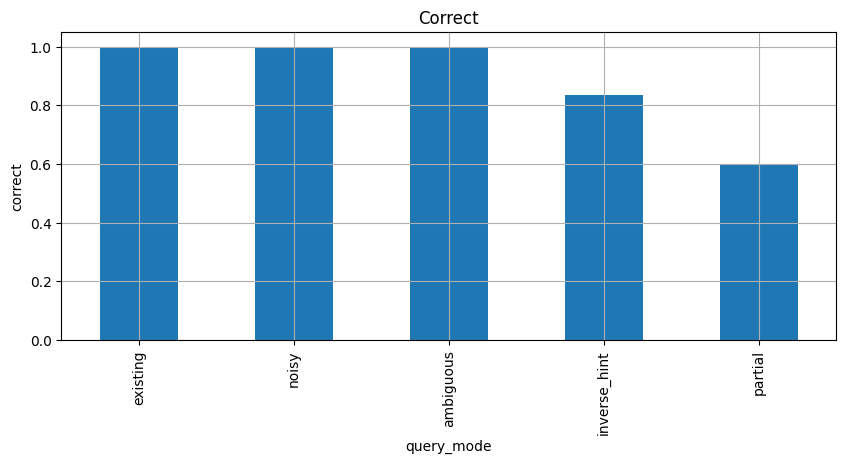

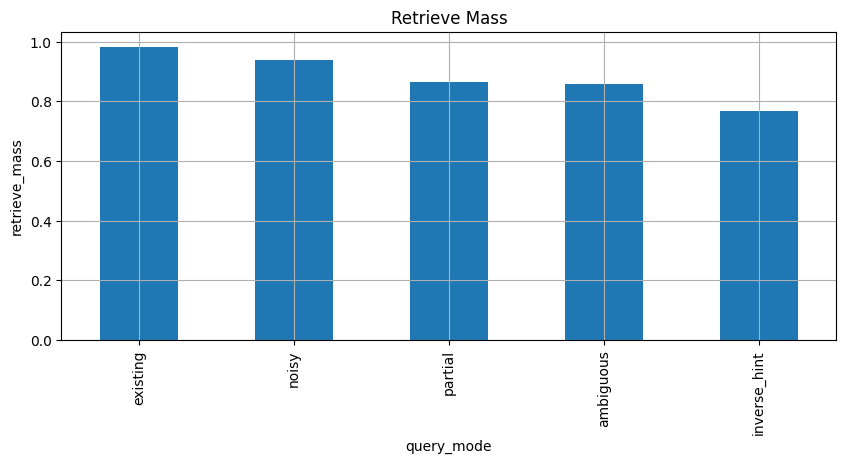

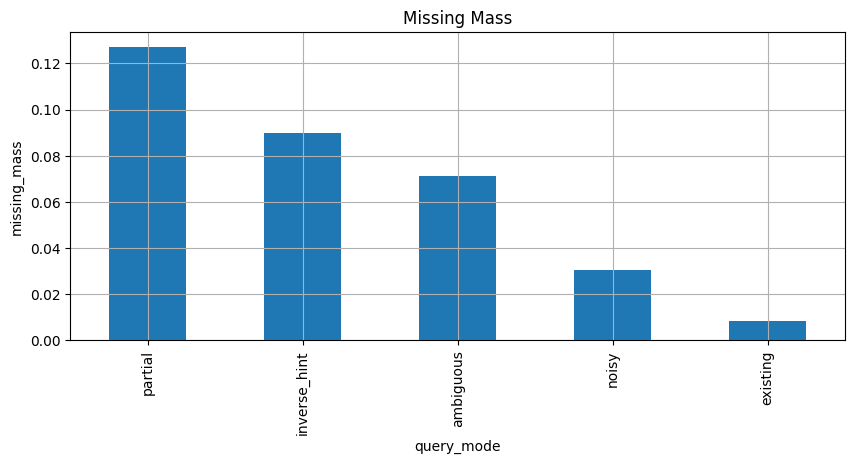

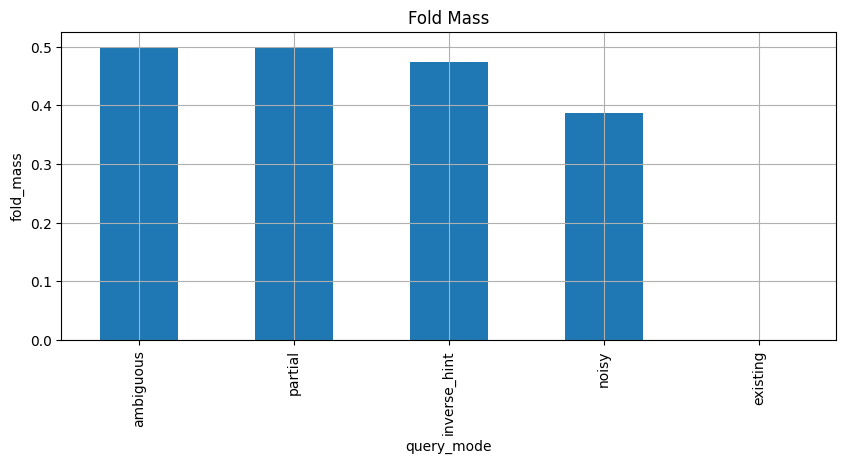

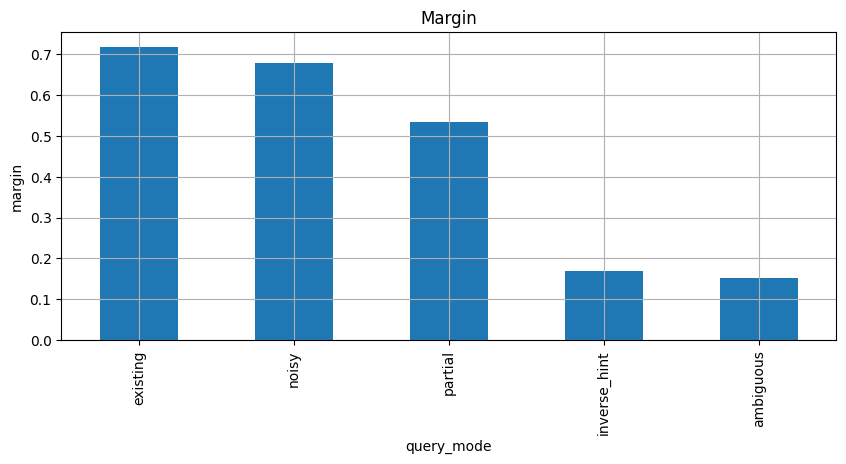

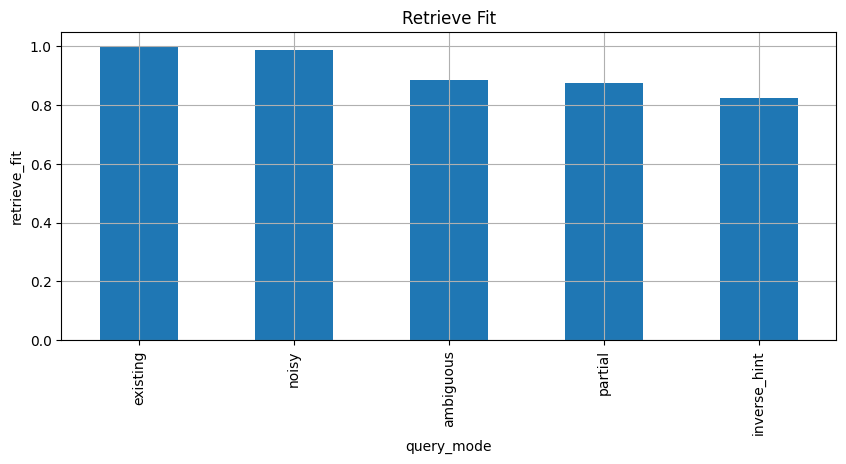

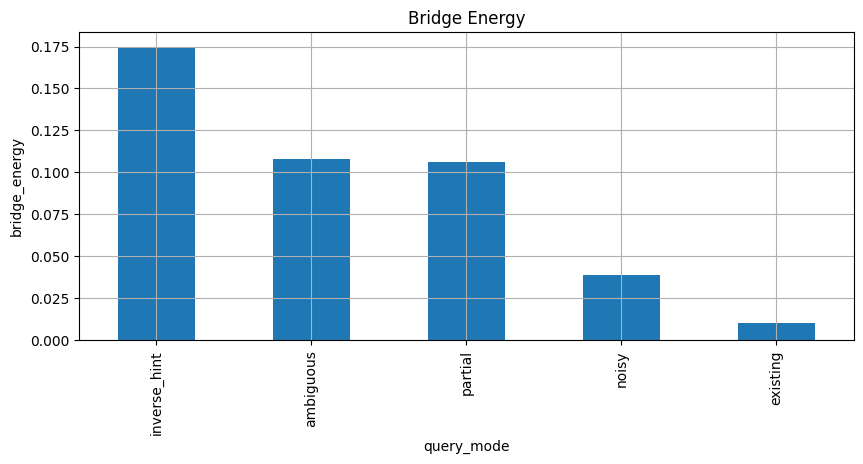

In [13]:

metrics = ["correct", "retrieve_mass", "missing_mass", "fold_mass", "margin", "retrieve_fit", "bridge_energy"]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = field_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()



## Practical readout

This notebook makes the controller output explicit:

$$
Q \to (\text{retrieve mask},\ \text{missing mask},\ \text{fold field},\ \text{declared value})
$$

That is the actual runtime object you wanted.

The calibrated split remains near:

- **35% retrieve**
- **65% grow**

And now the system gives:
- what already exists
- what is missing
- how to fold
- what the late value becomes

That is the next stable shape of the controller.
